# 1.1 Загрузить данные

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import datasets
from sklearn.datasets import load_diabetes
from sklearn.datasets import make_classification, make_blobs

In [93]:
data = load_diabetes()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# 1.2 Вывести таблицу с описанием данных и определить характер целевого свойства и оценить полноту данных

In [94]:
print('Список признаков:')
print(data.feature_names)

print('\nРазмер X:', X.shape)
print('Размер y:', y.shape)

print('\nИнформация о данных:')
df.info()

print('\nКоличество пропусков по столбцам:')
print(df.isnull().sum())

Список признаков:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Размер X: (442, 10)
Размер y: (442,)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Количество пропусков по столбцам:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


Набор данных содержит 442 объекта.

Матрица признаков X содержит 10 признаков. Целевая переменная y содержит 442 знаечния. Все данные числовые.

Пропущенные значения отсутствуют, данные являются полными

# 1.3 Постоить гистограмму для цели

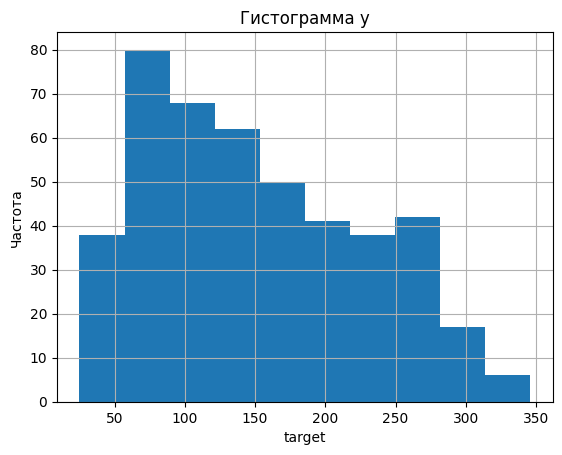

In [95]:
plt.hist(y)
plt.grid()
plt.xlabel('target')
plt.ylabel('Частота')
plt.title('Гистограмма y')
plt.show()

#1.4 Построить гистограммы для признаков

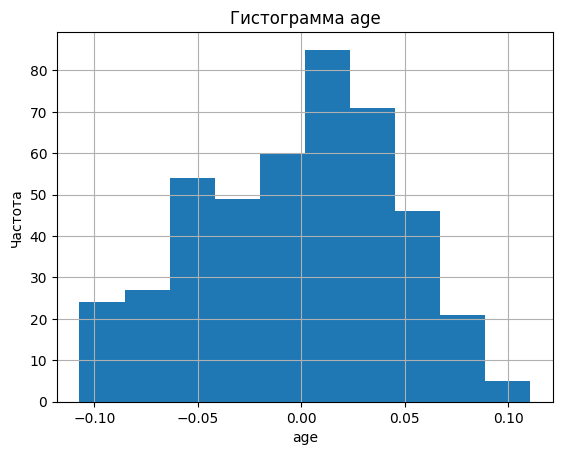

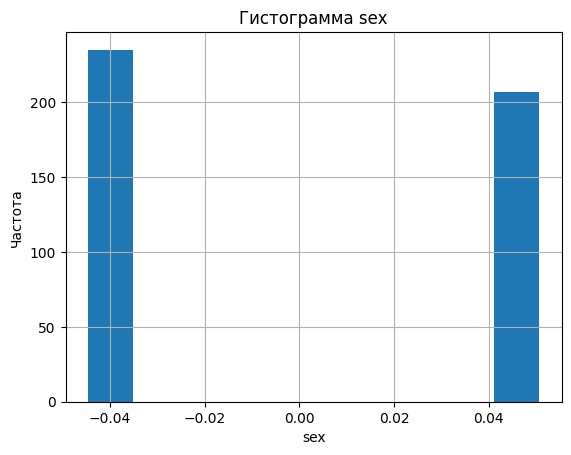

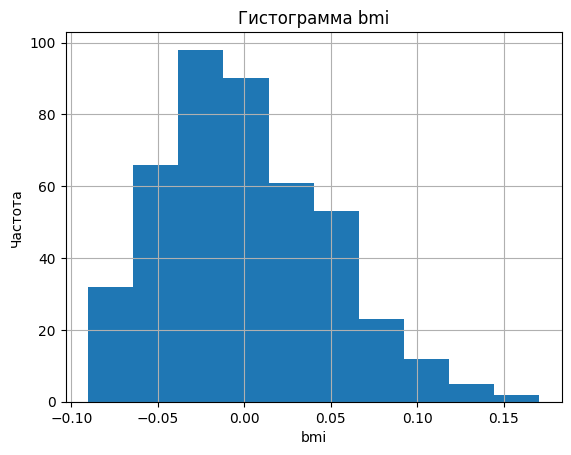

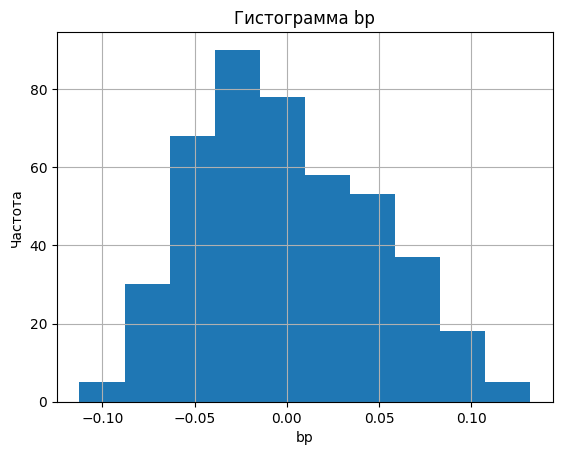

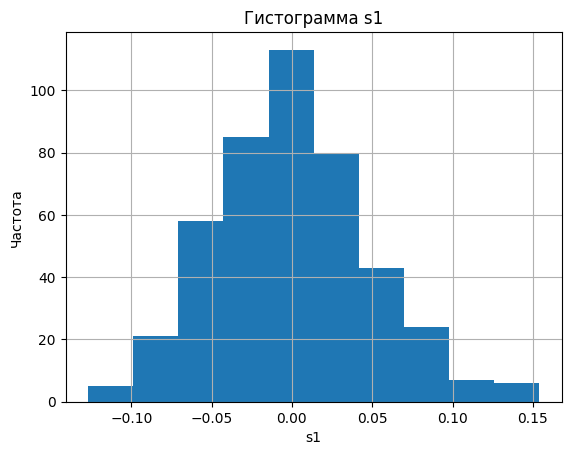

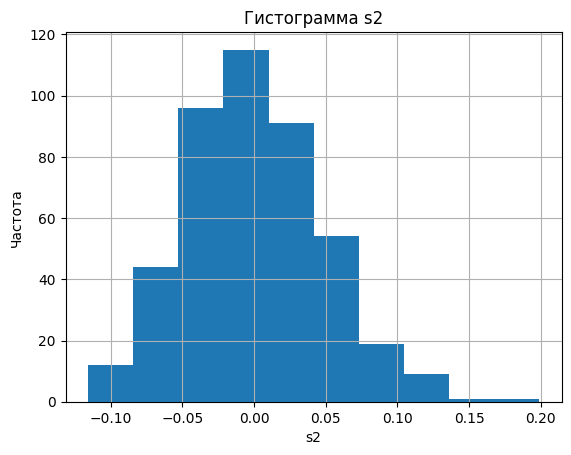

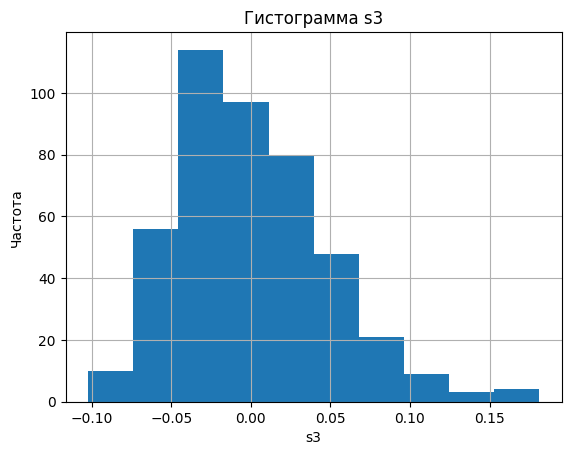

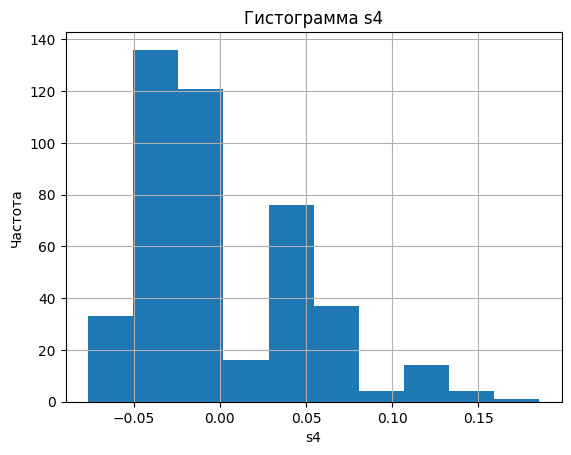

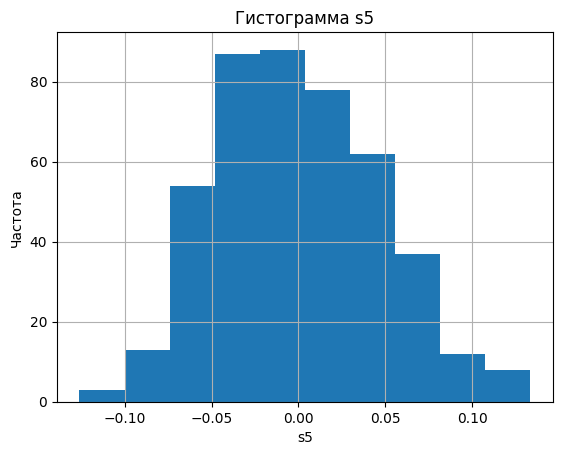

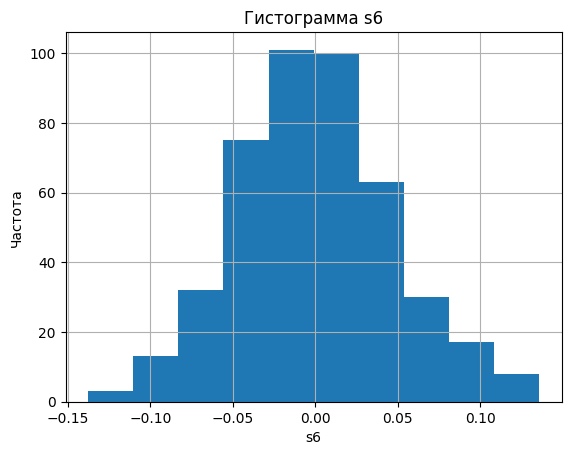

In [96]:
for i, name in enumerate(data.feature_names):
    plt.hist(X[:, i])
    plt.grid()
    plt.xlabel(name)
    plt.ylabel('Частота')
    plt.title('Гистограмма ' + name)
    plt.show()

#1.5 Сделать визуальную оценку характера распределения
Визуально видно, что распределения признаков имеют разный характер. Часть из них близка к симметричным, а другая часть имеет заметную ассиметрию и значительно отклоняется от нормальной формы

Целевая переменная не выглядит нормально распределённой. Для более точной оченки характера распределений необходимо дополнительно выполнить проверки нормальности

# 1.6 Оценить характер распределения опираясь на тесты нормальности

Для проверки нормальности используется тест Шапиро-Уилка при уровне значимости alpha = 0.05

Если p-value >= 0.05, значит нормальность отвергать нельзя

Если p-value < 0.05, нормальность отвергается

In [97]:
alpha = 0.05
stat, p = stats.shapiro(y)

print('Целевая переменная y')
print('W =', stat)
print('p-value =', p)

if p > alpha:
    print('H0 не отвергается')
else:
    print('H0 отвергается')
print()


Целевая переменная y
W = 0.9490577104821046
p-value = 3.3635438799024454e-11
H0 отвергается



In [98]:
for i, name in enumerate(data.feature_names):
    stat, p = stats.shapiro(X[:, i])

    print(name)
    print('W =', stat)
    print('p-value =', p)

    if p > alpha:
        print('H0 не отвергается')
    else:
        print('H0 отвергается')

    print()

age
W = 0.982357643169615
p-value = 3.278251483475348e-05
H0 отвергается

sex
W = 0.6350699653035219
p-value = 1.3975430094843643e-29
H0 отвергается

bmi
W = 0.9728212363035977
p-value = 2.519594252400323e-07
H0 отвергается

bp
W = 0.9836946020967955
p-value = 7.134736887213915e-05
H0 отвергается

s1
W = 0.9902794492440817
p-value = 0.005129251381489041
H0 отвергается

s2
W = 0.9883029057032983
p-value = 0.0013085811721350777
H0 отвергается

s3
W = 0.9631720082732766
p-value = 4.433757527831851e-09
H0 отвергается

s4
W = 0.9235619719787937
p-value = 3.274139081878305e-14
H0 отвергается

s5
W = 0.9911477153848268
p-value = 0.009556302449179368
H0 отвергается

s6
W = 0.9931230181792708
p-value = 0.040951062259475306
H0 отвергается



Полученные значения p-value для y и для всех числовых признаков меньше 0.05, поэтомуво всех случаях гипотеза о нормальности распределения отвергается.

Следовательно, строгий тест показал, что целевой признак y и признаки X не являются нормально распределёнными

# 1.7 Определить основной набор статистик для х и у

In [99]:
pd.DataFrame(y, columns=['target']).describe()

,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


In [100]:
pd.DataFrame(X, columns=data.feature_names).describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


# 1.8 Оцените факт наличия/отсутствия выбросов и охарактеризуйте качество данных (резюме предществующих пунктов)

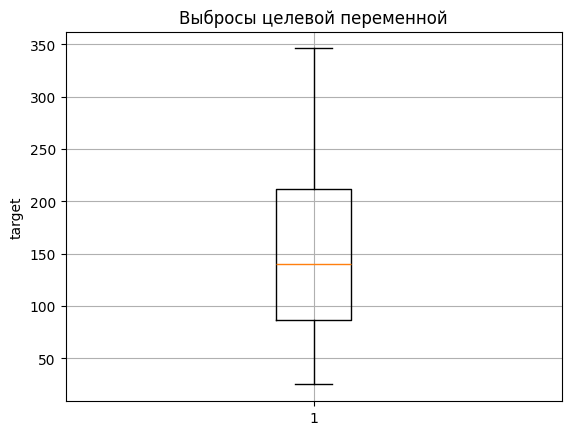

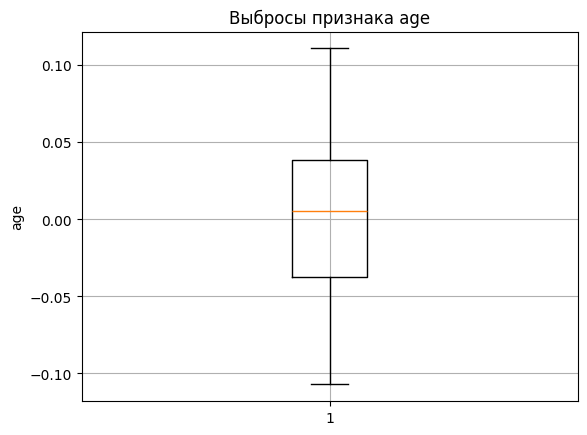

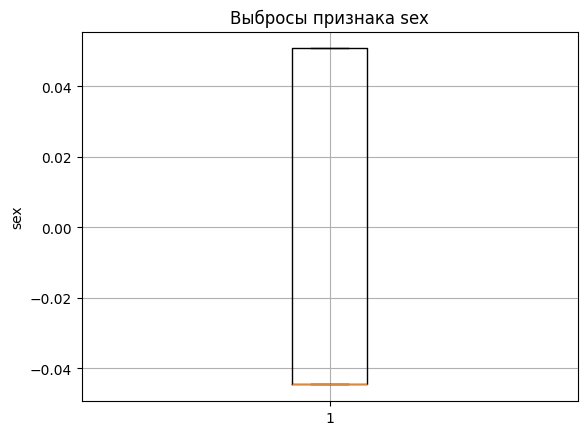

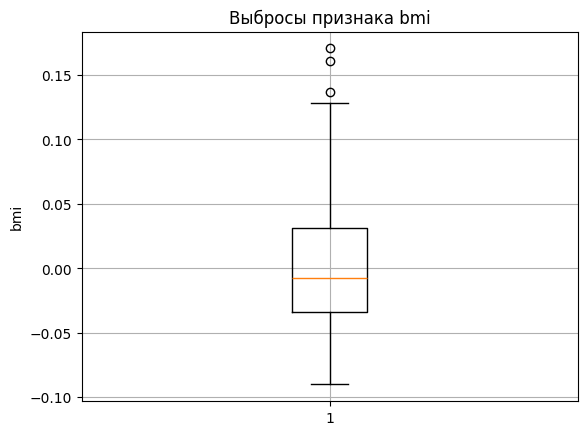

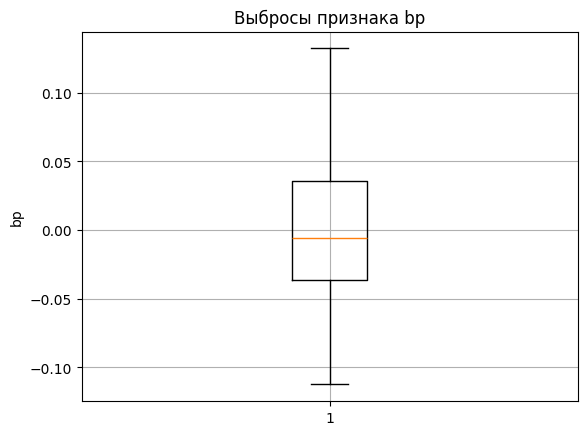

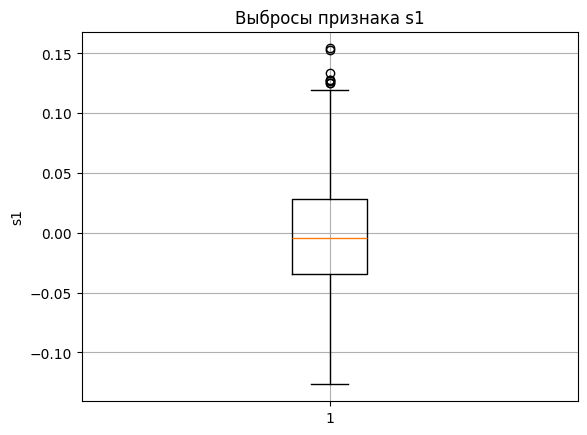

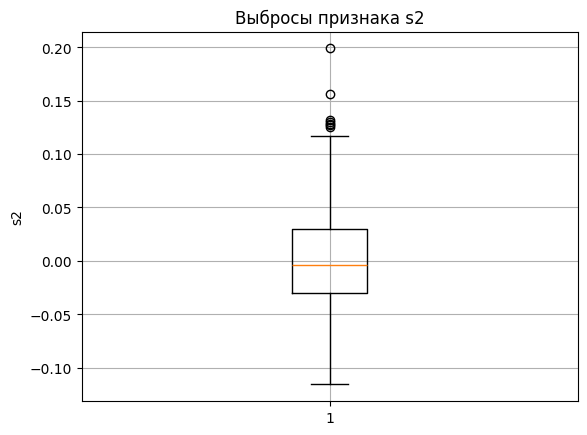

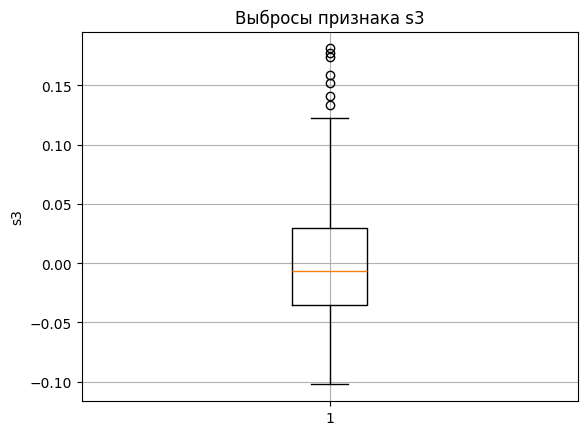

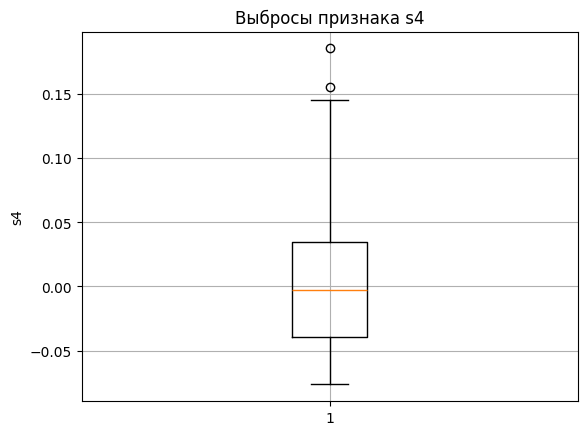

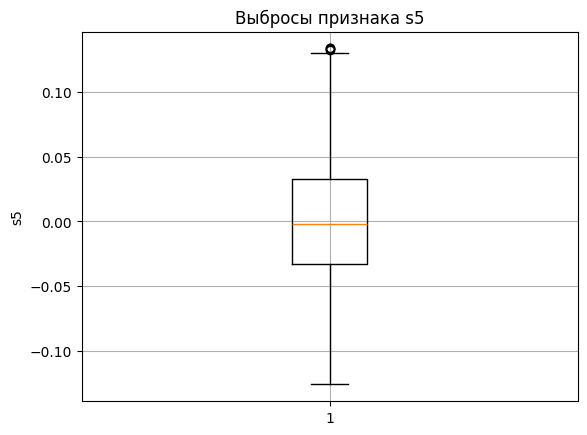

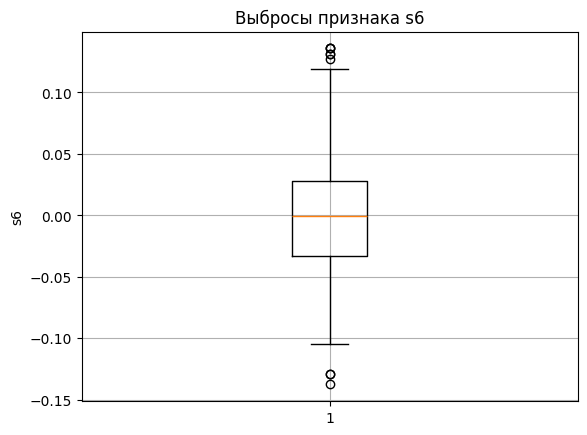

In [101]:
plt.boxplot(y)
plt.ylabel('target')
plt.title('Выбросы целевой переменной')
plt.grid()
plt.show()

for i, name in enumerate(data.feature_names):
    plt.boxplot(X[:, i])
    plt.ylabel(name)
    plt.title('Выбросы признака ' + name)
    plt.grid()
    plt.show()

In [102]:
outliers_count = {}

Q1 = np.quantile(y, 0.25)
Q3 = np.quantile(y, 0.75)
IQR = Q3 - Q1

outliers_count['target'] = (
    (y < Q1 - 1.5 * IQR) |
    (y > Q3 + 1.5 * IQR)
).sum()

for i, name in enumerate(data.feature_names):
    values = X[:, i]

    Q1 = np.quantile(values, 0.25)
    Q3 = np.quantile(values, 0.75)
    IQR = Q3 - Q1

    outliers_count[name] = (
        (values < Q1 - 1.5 * IQR) |
        (values > Q3 + 1.5 * IQR)
    ).sum()

pd.DataFrame(
    outliers_count.items(),
    columns=['Признак', 'Количество выбросов']
)

,Признак,Количество выбросов
0,target,0
1,age,0
2,sex,0
3,bmi,3
4,bp,0
5,s1,8
6,s2,7
7,s3,7
8,s4,2
9,s5,4


Для поиска выбросов используется "ящик с усами". Отдельные точки, находящиеся за усами диаграммы, являются потенциальными выбросами.

## Вывод по данным:
Набор данных пригоден для дальнейшего анализа и построения модели, поскольку:
* В данных отсутствуют пропущенные значения.
* Все признаки являются числовыми
* Целевая переменная и признаки не соответствуют нормальному распределению
* Небольшое количество выбросов у части признаков + отсутствие выбросов в целевой переменной





# 2.1  Создать синтетический набор данных для классификации на основе datasets.make_classification с числом классов 3, 3-мя информативными признаками и 3-мя избыточными, определить по 2 кластера в каждом классе и число примеров 1000

In [103]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=3,
    n_redundant=3,
    n_classes=3,
    n_clusters_per_class=2,
    random_state=1
)

print(X.shape)
print(y.shape)

print(np.unique(y))

(1000, 6)
(1000,)
[0 1 2]


# 2.2 Провести анализ полученных признаков : основные статистики, гистограммы, оценка нормальности

In [104]:
df_X = pd.DataFrame(X)
df_X.describe()

,0,1,2,3,4,5
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.316893,-0.010126,-0.020388,0.002520,-0.199187,0.157716
std,1.340098,1.429199,0.870296,1.364062,1.032849,1.082208
min,-3.872840,-3.841377,-2.769583,-3.385301,-3.310466,-2.277840
25%,-1.255753,-1.096563,-0.641281,-1.003967,-0.898954,-0.696495
50%,-0.481985,-0.097939,-0.040928,-0.056530,-0.177076,0.134690
75%,0.517498,1.016421,0.610799,1.046484,0.567252,0.922853
max,3.425395,4.374001,2.553510,3.985966,2.159805,3.383978


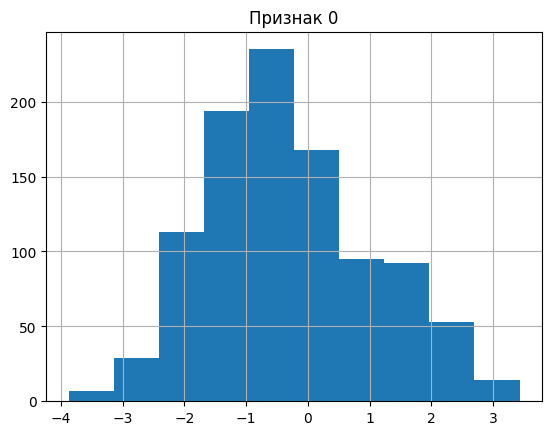

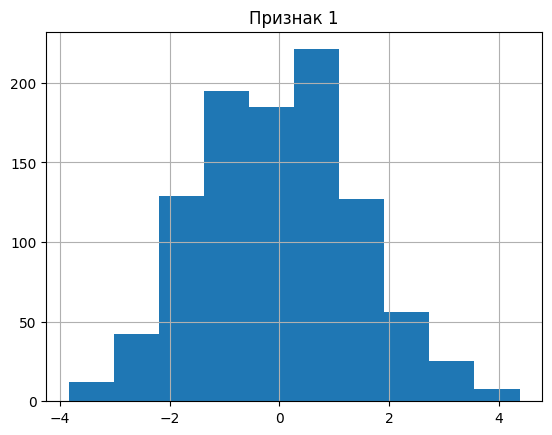

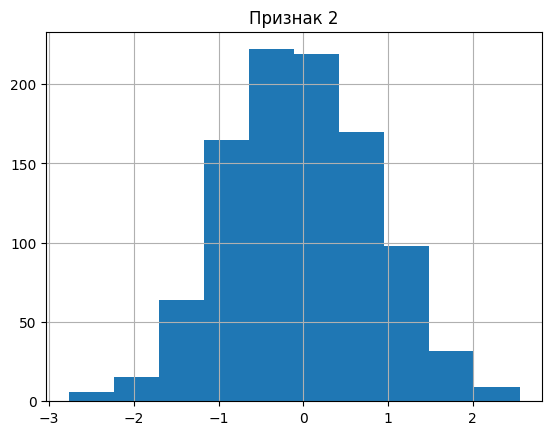

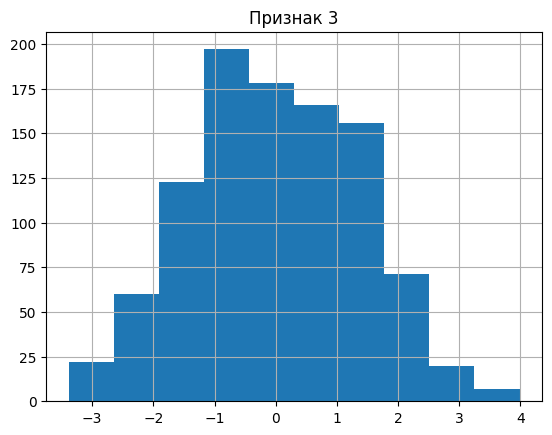

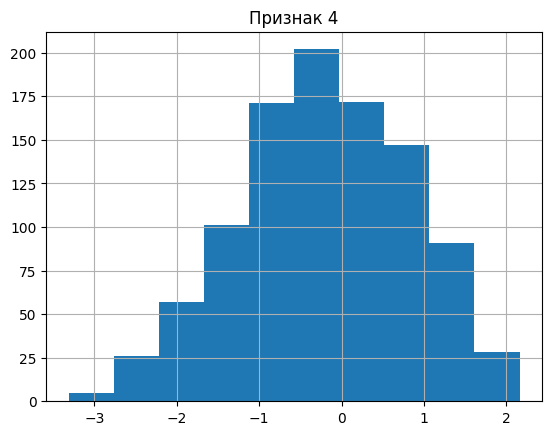

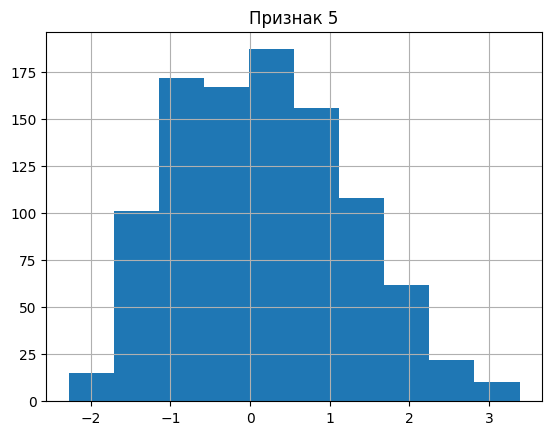

In [105]:
for name in df_X.columns:
    plt.hist(df_X[name])
    plt.grid()
    plt.title('Признак ' + str(name))
    plt.show()

In [106]:
alpha = 0.05

for name in df_X.columns:

    stat, p = stats.shapiro(df_X[name])

    print('Признак', name)
    print('W =', stat)
    print('p-value =', p)

    if p > alpha:
        print('H0 не отвергается')
    else:
        print('H0 отвергается')

    print()

Признак 0
W = 0.9845615643786854
p-value = 8.695878126124623e-09
H0 отвергается

Признак 1
W = 0.9915486592812746
p-value = 1.7065166724486918e-05
H0 отвергается

Признак 2
W = 0.9977903091923248
p-value = 0.205552508157671
H0 не отвергается

Признак 3
W = 0.9940252178091235
p-value = 0.0005094929187887965
H0 отвергается

Признак 4
W = 0.9934503857671252
p-value = 0.00022177927389472577
H0 отвергается

Признак 5
W = 0.9850110021871333
p-value = 1.3261541860137329e-08
H0 отвергается



# 2.3 Создать синтетический набор данных для классификации на основе datasets.make_blobs с числом источников 3, 2-мя признаками и числом примеров 1000

(1000, 2)
(1000,)
[0 1 2]


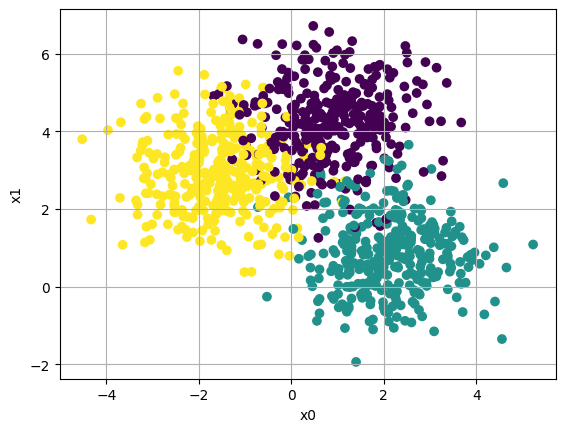

In [107]:
X_blobs, y_blobs = datasets.make_blobs(
    n_samples=1000,
    centers=3,
    n_features=2,
    random_state=0
)

print(X_blobs.shape)
print(y_blobs.shape)

print(np.unique(y_blobs))

plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=y_blobs
)

plt.grid()
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

# 2.4 Провести анализ полученных признаков : основные статистики, гистограммы, оценка нормальности

In [108]:
df_blobs = pd.DataFrame(X_blobs)
df_blobs.describe()

,0,1
count,1000.000000,1000.000000
mean,0.474105,2.693101
std,1.812607,1.706040
min,-4.521517,-1.936891
25%,-1.041722,1.302741
50%,0.675845,2.801684
75%,1.885744,4.047832
max,5.226242,6.716241


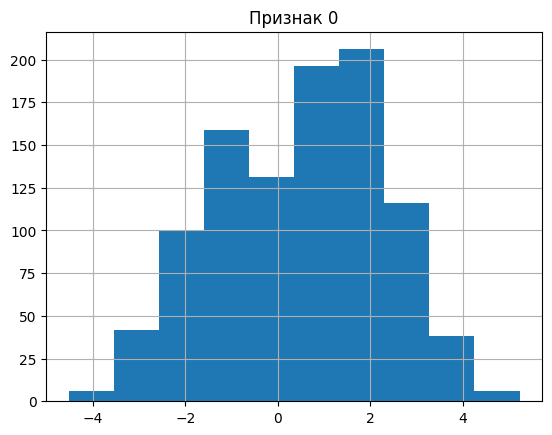

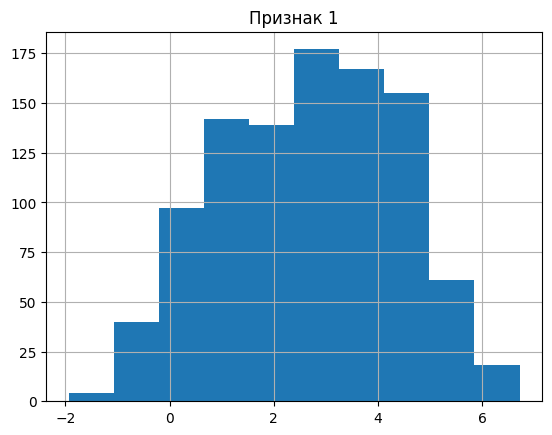

In [109]:
for name in df_blobs.columns:
    plt.hist(df_blobs[name])
    plt.grid()
    plt.title('Признак ' + str(name))
    plt.show()

In [110]:
alpha = 0.05

for name in df_blobs.columns:

    stat, p = stats.shapiro(df_blobs[name])

    print('Признак', name)
    print('W =', stat)
    print('p-value =', p)

    if p > alpha:
        print('H0 не отвергается')
    else:
        print('H0 отвергается')

    print()

Признак 0
W = 0.9819407071086523
p-value = 8.485363145389635e-10
H0 отвергается

Признак 1
W = 0.9854449495032301
p-value = 2.0072734526284955e-08
H0 отвергается



# 3 Сделать EDA для набора

# Вариант: avocado
Целевая переменная: AveragePrice

Признаки: все остальные признаки предикторы

# 3.1 Открыть набор данных по варианту

In [111]:
df = pd.read_csv('avocado.csv')

print('Файл avocado.csv загружен')
df.head()

Файл avocado.csv загружен


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# 3.2 Перейти к табличной форме отображения (или обратно, если в наборе таблица)

In [112]:
X_table = df.drop(columns='AveragePrice')
Y_table = df['AveragePrice']

X = X_table.to_numpy()
Y = Y_table.to_numpy()

print('Тип X:', type(X))
print('Тип Y:', type(Y))

print('\nРазмер X:', X.shape)
print('Размер Y:', Y.shape)

print('\nДо перехода:')
print(type(df))

data_array = df.to_numpy()

print('\nПосле перехода:')
print(type(data_array))

Тип X: <class 'numpy.ndarray'>
Тип Y: <class 'numpy.ndarray'>

Размер X: (18249, 13)
Размер Y: (18249,)

До перехода:
<class 'pandas.core.frame.DataFrame'>

После перехода:
<class 'numpy.ndarray'>


Исходный набор данных представлен в табличной форме DataFrame. Для дальнейшей работы выполнено преобразование данных в массивы

X содержит все 12 признаков набора данных

y содержит значения целевого свойства AveragePrice

# 3.3 Описать переменные: (определить зависимую переменную (целевое свойство, если есть), описать типы переменных)


### Зависимая переменная:

AveragePrice - средняя цена авокадо. Это числовая непрерывная переменная

In [113]:
print('Тип данных:', df['AveragePrice'].dtype)

Тип данных: float64


### Типы переменных:

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


Unnamed - технический столбец с индексами строк

AveragePrice, Total Volume, 4046, 4225, 4770, Total Bags, Small Bags, Large Bags и XLarge Bags, year являются числовыми переменными

type и region являются категориальными переменными, содержащими названия категорий

Date является временной переменной, содержащей дату наблюдения

# 3.4 Оценить число примеров (найти целевую переменную или группу целевых перемен-ных У и признаки для описания целевой переменной предикторы Х)

Перед выполнением данного пункта удалю столбец Unnamed: 0, т.к. он не является признаком

In [115]:
df = df.drop(columns=['Unnamed: 0'])

Y = df['AveragePrice']
X = df.drop(columns=['AveragePrice'])

print('Количество примеров:', df.shape[0])
print('Количество признаков X:', X.shape[1])
print('Количество значений y:', Y.shape[0])

print('\nЦелевая переменная y:')
print(Y.name)

print('\nПризнаки X:')
print(X.columns.tolist())

Количество примеров: 18249
Количество признаков X: 12
Количество значений y: 18249

Целевая переменная y:
AveragePrice

Признаки X:
['Date', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']


# 3.5 Выдвинуть гипотезы о характере распределений и сделать анализ

### Гипотезы:

*   AveragePrice - предпологается распределение с основной массой значений в некотором среднем диапазоне, возможна небольшая ассиметрия
*   Total Volume, 4046, 4225, 4770 - поскольку это объёмы продаж, можно предположить правостороннюю ассиметрию. Большинство наблюдений могут иметь небольшие значения, а отдельные наблюдения могут быть очень большими
*   Total Bags, Small Bags, Large Bags, XLarge Bags - ождиается правосторонняя ассиметрия и наличие редких больших значений
*   type, region - категориональные признаки. Для них будет проведен анализ частоты значений
*   year - принимает небольшое количество отдельных значений, поэтому будет проведен анализ частоты значений
*   Date - временной признак, поэтому проверка нормальности к нему не применяется







### Числовые признаки

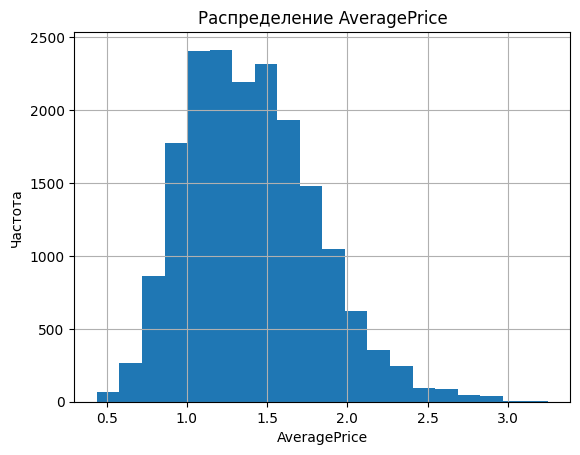

In [116]:
plt.hist(df['AveragePrice'], bins=20)
plt.grid()
plt.xlabel('AveragePrice')
plt.ylabel('Частота')
plt.title('Распределение AveragePrice')
plt.show()


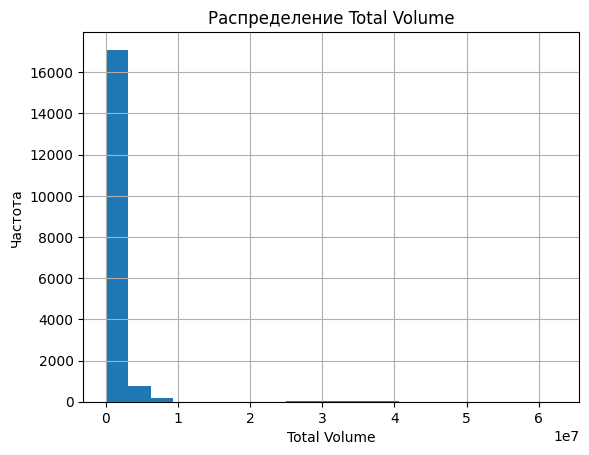

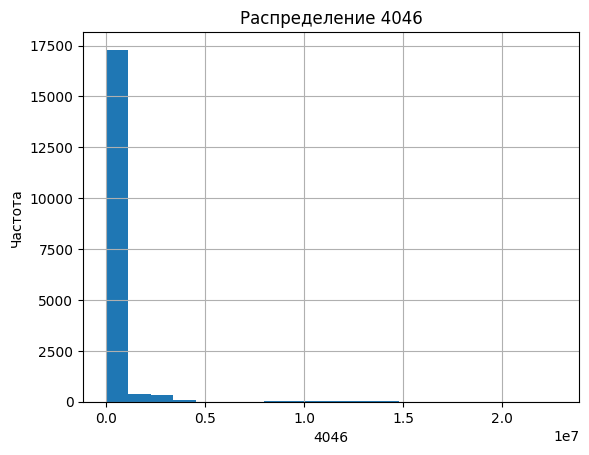

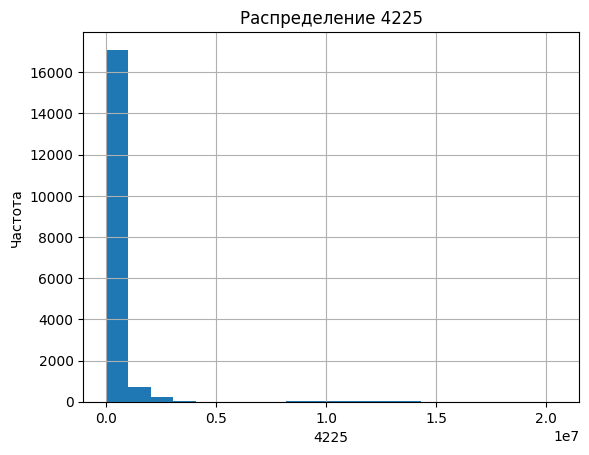

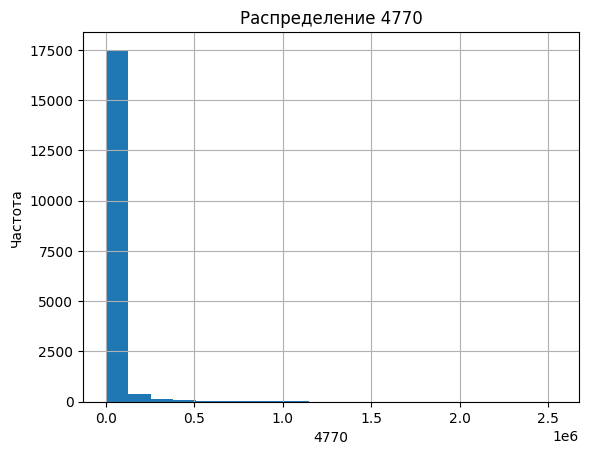

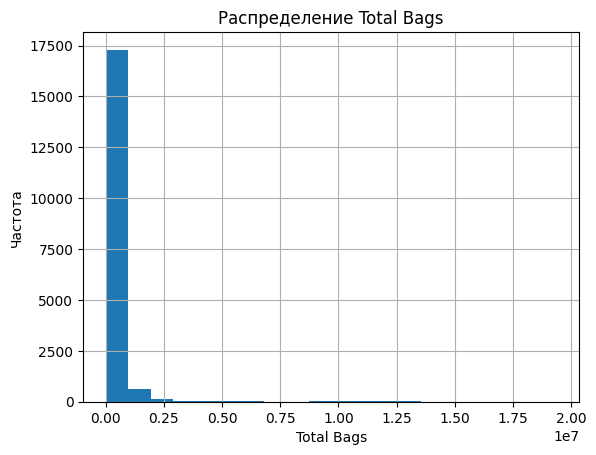

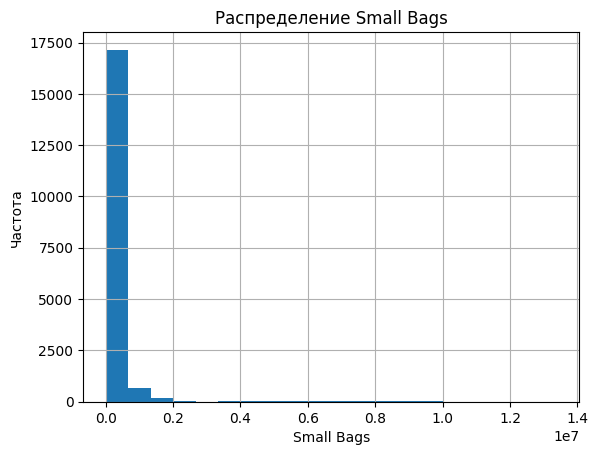

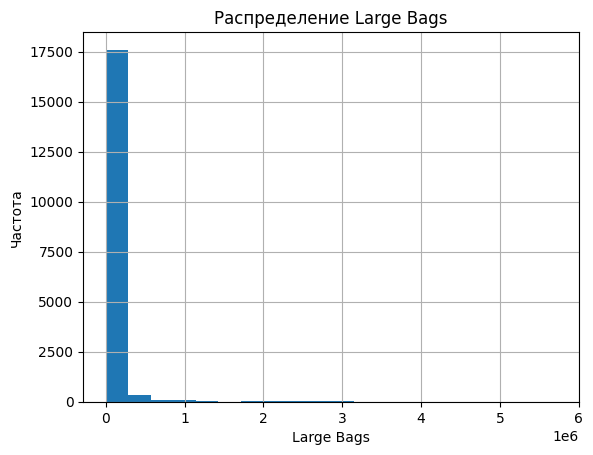

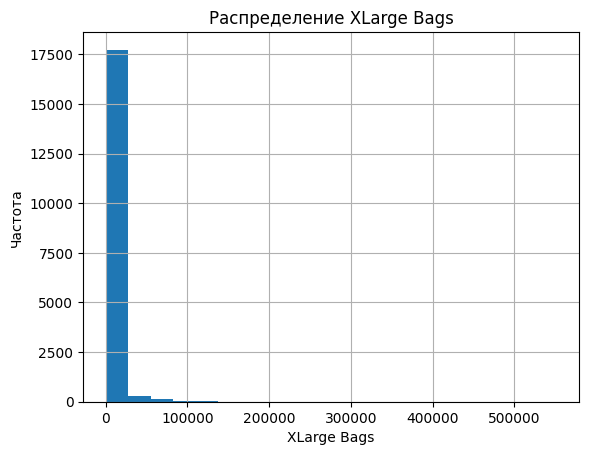

In [117]:
numeric_features = [
    'Total Volume',
    '4046',
    '4225',
    '4770',
    'Total Bags',
    'Small Bags',
    'Large Bags',
    'XLarge Bags'
]

for name in numeric_features:
    plt.hist(df[name], bins=20)
    plt.grid()
    plt.xlabel(name)
    plt.ylabel('Частота')
    plt.title('Распределение ' + name)
    plt.show()

### Числовой признак year

Количество наблюдений по годам:


,count
year,
2015,5615
2016,5616
2017,5722
2018,1296


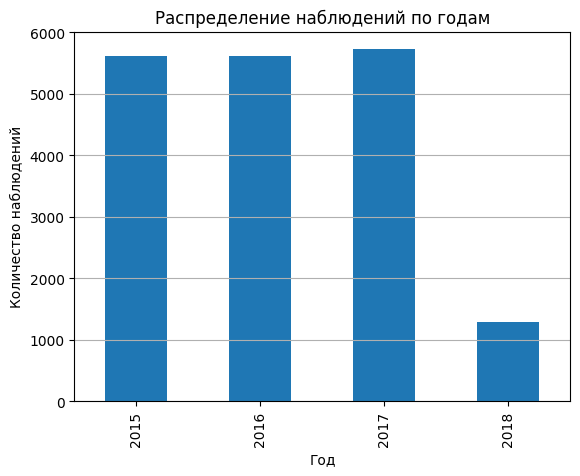

In [118]:
year_counts = df['year'].value_counts().sort_index()

print('Количество наблюдений по годам:')
display(year_counts)

year_counts.plot(kind='bar')

plt.grid(axis='y')
plt.xlabel('Год')
plt.ylabel('Количество наблюдений')
plt.title('Распределение наблюдений по годам')
plt.show()

### Категориальные признаки



Распределение type:


,count
type,
conventional,9126
organic,9123


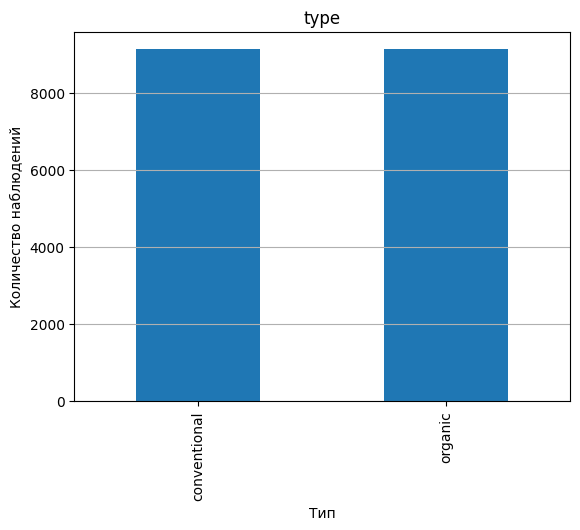

Распределение type:


,count
type,
conventional,9126
organic,9123


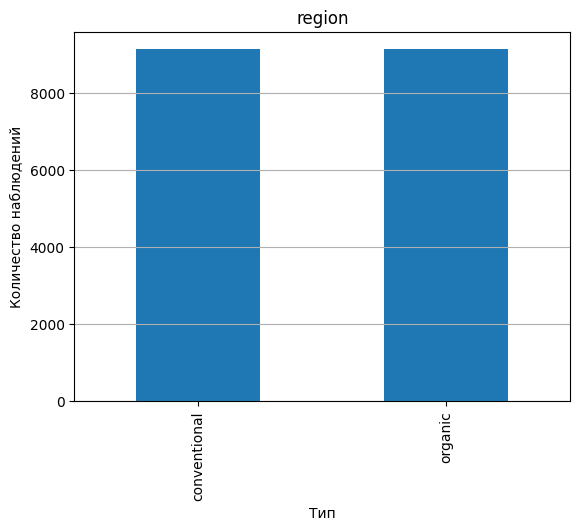

In [119]:
type_counts = df['type'].value_counts()

print('Распределение type:')
display(type_counts)

type_counts.plot(kind='bar')

plt.grid(axis='y')
plt.xlabel('Тип')
plt.ylabel('Количество наблюдений')
plt.title('type')
plt.show()

type_counts = df['type'].value_counts()

print('Распределение type:')
display(type_counts)

type_counts.plot(kind='bar')

plt.grid(axis='y')
plt.xlabel('Тип')
plt.ylabel('Количество наблюдений')
plt.title('region')
plt.show()

### Проверка нормальности числовых признаков

Для проверки нормальности используется тест Шапиро-Уилка при уровне значимости alpha = 0.05

Если p-value >= 0.05, значит нормальность отвергать нельзя

Если p-value < 0.05, нормальность отвергается


In [120]:
alpha = 0.05

values = df['AveragePrice']

values = values.sample(5000, random_state=42)

stat, p = stats.shapiro(values)

print('AveragePrice')
print('W =', stat)
print('p-value =', p)

if p > alpha:
    print('H0 не отвергается')
else:
    print('H0 отвергается')
print()

for name in x.select_dtypes(include='number').columns:
    values = x[name]

    values = values.sample(5000, random_state=42)

    stat, p = stats.shapiro(values)

    print(name)
    print('W =', stat)
    print('p-value =', p)

    if p > alpha:
        print('H0 не отвергается')
    else:
        print('H0 отвергается')
    print()

AveragePrice
W = 0.980891537733232
p-value = 1.9622019605442621e-25
H0 отвергается

Total Volume
W = 0.2130714369575114
p-value = 2.9144717987453533e-90
H0 отвергается

4046
W = 0.2048052527192562
p-value = 1.6761985625733145e-90
H0 отвергается

4225
W = 0.22472196322605653
p-value = 6.410719404088348e-90
H0 отвергается

4770
W = 0.20796289172609728
p-value = 2.0693600842743917e-90
H0 отвергается

Total Bags
W = 0.20555835837383696
p-value = 1.7624720516621614e-90
H0 отвергается

Small Bags
W = 0.20862016582352982
p-value = 2.162341328339365e-90
H0 отвергается

Large Bags
W = 0.19653526495389917
p-value = 9.686029096396091e-91
H0 отвергается

XLarge Bags
W = 0.15320346099097493
p-value = 5.915601344532143e-92
H0 отвергается

year
W = 0.8562683219691232
p-value = 1.644675512978627e-55
H0 отвергается



### Сводные статистики

In [121]:
df[numeric_features].describe()

,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags
count,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000
mean,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507
std,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652
min,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000
50%,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000
75%,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000
max,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000


### Вывод по распределениям

*   AveragePrice - имеет распределение с основной массой значений в среднем диапазоне и небольшой правосторонней асимметрией. Согласно критерию Шапиро-Уилка нормальность распределения отвергается
*   Total Volume, 4046, 4225, 4770 - имеет выраженную правостороннюю ассиметрию, при которой большинство значений сравнительно небольшие, но присутствуют очень большие значения. Согласно критерию Шапиро-Уилка нормальность распределения отвергается
*   Total Bags, Small Bags, Large Bags, XLarge Bags -
распределения сильно смещены вправо и содержат крупные значения. Согласно критерию Шапиро-Уилка нормальность распределения отвергается

В общих чертах выдвинутые гипотезы подтвердились с помощью визуального и статичтического анализа



# 3.6 Оценить пропуски

In [122]:
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков': (df.isna().mean() * 100).round(2)
})

display(missing)

print('Общее количество пропусков:', df.isna().sum().sum())

,Количество пропусков,Процент пропусков
Date,0,0.0
AveragePrice,0,0.0
Total Volume,0,0.0
4046,0,0.0
4225,0,0.0
4770,0,0.0
Total Bags,0,0.0
Small Bags,0,0.0
Large Bags,0,0.0
XLarge Bags,0,0.0


Общее количество пропусков: 0


В исследуемом наборе данных пропущенные значения отсутствуют. Для всех признаков и целевой переменной количество и процент пропусков равны нулю.

Учитывая это, дополнительная обработка пропущенных значений не требуется

# 3.7 Предложить вариант задачи относительно выборки из вашего варианта (классифика-ция, регрессия, кластеризация …..)

Целевая переменная AveragePrice является числовой непрерывной величиной, поэтому для предложенного набора наиболее подходящей является задача регрессии

Возможная формулировка задачи:

Построить модель для прогнозирования средней цены авокадо на основе набора данных (объёмов продаж, количества упаковок, типа авокадо, региона, года и даты наблюдения)

Для данной задачи:
*   Y - AveragePrice
*   X - остальные признаки набора данных

Результатом модели будет прогноз числового значения средней цены авокадо




